In [1]:
import os
import gzip
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def read_idx(filename):
    open_fn = gzip.open if filename.endswith('.gz') else open
    with open_fn(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(path_imgs, path_labels):
    X = read_idx(path_imgs)
    y = read_idx(path_labels)
    
    X= X.astype('float32')
    X /= 255
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    return X_train, y_train, X_test, y_test

Dataset shape: 48000 [n_images,hight,width]


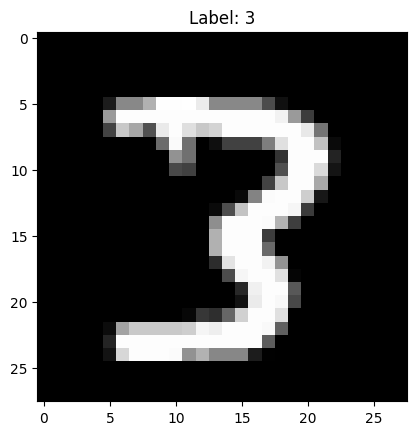

In [2]:
imgs = 'train-images-idx3-ubyte.gz'
labels = 'train-labels-idx1-ubyte.gz'

X_train, y_train, X_test, y_test = load_data(imgs, labels)

print('Dataset shape:', X_train.shape[0], "[n_images,hight,width]")
plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['acc'])

    return model

In [4]:
create_model((28, 28), 10).summary()

c:\Users\josej\Documents\pythonCode\TripleTen\tfenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,018 (207.10 KB)

 Trainable params: 53,018 (207.10 KB)

 Non-trainable params: 0 (0.00 B)

Crea la función train_model() para entrenar un modelo de red neuronal dado utilizando los datos de entrenamiento proporcionados y evalúalo en los datos de prueba.

La función debe aceptar los siguientes parámetros:
model: el modelo de red neuronal a entrenar.
train_data: una tupla que contiene las características y los objetivos de entrenamiento.
test_data: una tupla que contiene las características y objetivos de prueba.
batch_size: el tamaño del lote para el entrenamiento (de forma predeterminada es 32).
epochs: el número de épocas para el entrenamiento (de forma predeterminada es 5).
Utiliza el método fit() sobre el objeto model para entrenar a tu modelo. Además:
Pasa los parámetros de los conjuntos de datos de entrenamiento y de prueba al método fit. Para el entrenamiento, X y Y deben pasarse independientemente. Para la validación, puedes pasarlos como una tupla.
Utiliza los batch_size y epochs especificados para entrenar tu modelo.
Establece verbose=2 para un registro detallado durante el entrenamiento.
Baraja los datos de entrenamiento con shuffle=True.
Devuelve el modelo entrenado utilizando todas las funciones implementadas previamente.

In [12]:
train_images_path = 'train-images-idx3-ubyte.gz'
train_labels_path = 'train-labels-idx1-ubyte.gz'

In [6]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def read_idx(filename):
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(path):
    X = read_idx(train_images_path)
    y = read_idx(train_labels_path)
    
    X= X.astype('float32')
    X /= 255
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    return X_train, y_train, X_test, y_test

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Capa de salida
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    
    return model

# Crea una función que entrene tu modelo.
def train_model():
    history  = # TU CÓDIGO
    return history
    
# Rutas a tu conjunto de datos
imgs = # Reemplaza esta ruta por la tuya. Ejemplo: '/dataset/train-images.idx3-ubyte'
labels = # Reemplaza esta ruta por la tuya. Ejemplo: '/dataset/train-labels.idx1-ubyte'

## Llama a tu función load_data()
X_train, y_train, X_test, y_test = # pasa la ruta a tus imágenes y etiquetas

# crea y entrena el modelo
model = create_model("agrega el parámetro definido anteriormente")
trained_model = train_model( 
                  "la variable de tu modelo",
                  "tu conjunto de entrenamiento",
                  "tu conjunto de prueba",
                  batch_size="define un tamaño de batch",
                  epochs="define el número de épocas",
                  verbose="define el número de verbose")

SyntaxError: invalid syntax (2016231049.py, line 44)

In [14]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def read_idx(filename):
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

def load_data(path):
    X = read_idx(train_images_path)
    y = read_idx(train_labels_path)
    
    X= X.astype('float32')
    X /= 255
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    return X_train, y_train, X_test, y_test

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Capa de salida
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    
    return model
    
def train_model(model,train_data, test_data, batch_size=32, epochs=5):
    history = model.fit(train_data[0],train_data[1],
                    validation_data=test_data,
                    batch_size=batch_size, 
                    epochs=epochs,
                    shuffle=True,
                    verbose=2)
    return history

imgs = '/dataset/train-images.idx3-ubyte'
labels = '/dataset/train-labels.idx1-ubyte'

X_train, y_train, X_test, y_test = load_data(imgs, labels)
    
model = create_model((28, 28), 10)
model_trained = train_model(model, 
                        (X_train,y_train),
                        (X_test,y_test),
                        batch_size=32,
                        epochs=10,
                        verbose=1)

TypeError: load_data() takes 1 positional argument but 2 were given

In [7]:
def convolve(sequence, weights):
    convolution = np.zeros(len(sequence) - len(weights) + 1)
    for i in range(convolution.shape[0]):
        convolution[i] = np.sum(
            np.array(weights) * np.array(sequence[i : i + len(weights)])
        )
    return convolution



In [8]:
s = [2, 3, 5, 7, 11]
w = [-1, 1]

convolve(s, w)

array([1., 2., 2., 4.])

In [ ]:
s = [[2, 1, 3], 
     [4, 0, 2], 
     [1, 5, 6]]
w = [[-1, -2], 
     [1,   2]]

convolve(s, w)

ValueError: operands could not be broadcast together with shapes (2,2) (2,3) 

# Modelo Adam

In [9]:
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.layers import Conv2D, Flatten, Dense, AvgPool2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np

def load_data():
    (features_train, target_train), (features_test, target_test) = fashion_mnist.load_data()
    features_train = features_train.reshape(-1, 28, 28, 1) / 255.0
    features_test = features_test.reshape(-1, 28, 28, 1) / 255.0
    return (features_train, target_train), (features_test, target_test)

def create_model(input_shape):
    model = Sequential()
    
    # Añade la primera capa convolucional aquí

    model.add(AvgPool2D(pool_size=(2, 2)))

    # Añade la segunda capa convolucional aquí

    model.add(AvgPool2D(pool_size=(2, 2)))

    # Añade una capa flatten aquí

    model.add(Dense(120, activation='relu'))
    model.add(Dense(84, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    optimizer = # Establece el optimizador Adam aquí

    model.compile(
        optimizer= optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['acc'],
    )

    return model

def train_model(
        model,
        train_data,
        test_data,
        batch_size=32,
        epochs=5,
        steps_per_epoch=None,
        validation_steps=None,
):

    features_train, target_train = train_data
    features_test, target_test = test_data

    model.fit(
        features_train,
        target_train,
        validation_data=(features_test, target_test),
        batch_size=batch_size,
        epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2,
        shuffle=True,
    )

    return model

train_data, test_data = load_data()
input_shape = (28, 28, 1)
model = create_model(input_shape)

model_fitted = train_model(model,
                           train_data,
                           test_data,
                           epochs=2
                           )

SyntaxError: invalid syntax (2107570666.py, line 30)

In [ ]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def read_idx(filename):
    with open(filename, 'rb') as f:
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)


def load_data(path):
    X = read_idx(train_images_path)
    y = read_idx(train_labels_path)
    
    X= X.astype('float32')
    X /= 255
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
    
    return X_train, y_train, X_test, y_test

def create_model(input_shape, num_classes):
    model = Sequential()
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))  # Capa de salida
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['acc'])
    
    return model
    
def train_model(model,train_data, test_data, batch_size=32, epochs=5):
    history = model.fit(train_data[0],train_data[1],
                    validation_data=test_data,
                    batch_size=batch_size, 
                    epochs=epochs,
                    shuffle=True,
                    verbose=2)
    return history

imgs = '/dataset/train-images.idx3-ubyte'
labels = '/dataset/train-labels.idx1-ubyte'

X_train, y_train, X_test, y_test = load_data(imgs, labels)
    
model = create_model((28, 28), 10)
model_trained = train_model(model, 
                        (X_train,y_train),
                        (X_test,y_test),
                        batch_size=32,
                        epochs=10,
                        verbose=1)

ValueError: cannot reshape array of size 9912386 into shape (2055376946,226418,1634299437,1768776039,1702047337,1685599021,1969387892,1694559388)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
    
datagen = ImageDataGenerator(validation_split=0.25)

train_datagen_flow = datagen.flow_from_directory(
    '/datasets/fruits_small/',
    target_size=(150, 150),
    batch_size=16,
    class_mode='sparse',
    subset='training',
    seed=12345,
)


val_datagen_flow = val_datagen_flow = datagen.flow_from_directory(
    '/datasets/fruits_small/',
    target_size=(150, 150),
    batch_size=16,
    class_mode='sparse',
    subset='validation',
    seed=12345,
)

model = Sequential()
model.add(
    Conv2D(
        filters=6,
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(150, 150, 3),
    )
)
model.add(AveragePooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=12, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['acc']
)

model.fit(train_datagen_flow,
          validation_data=val_datagen_flow,
          # Para evitar entrenarlo por demasiado tiempo
          # determina el número de pasos en 1
          steps_per_epoch=1,
          validation_steps=1,
          verbose=2, epochs=1)

FileNotFoundError: [WinError 3] El sistema no puede encontrar la ruta especificada: '/datasets/fruits_small/'

In [18]:
ImageDataGenerator().help()

AttributeError: 'ImageDataGenerator' object has no attribute 'help'